## <center> Oath Path </center>

## <center> Assessment </center>

## <center> Position : GeoSpatial Analyst Internship </center>

##### <center> Name : Rose Kawila Kyalo </center>
##### <center> Date: 25th March 2026 </center>

In [ ]:
# Import libraries
import numpy as np                          
import pandas as pd                         
import matplotlib.pyplot as plt             
import seaborn as sns 
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap  
import matplotlib.colors as mcolors                   
import rasterio                             
import geopandas as gpd       
from shapely.geometry import box             
from sklearn.ensemble import RandomForestClassifier  
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder        
import warnings
warnings.filterwarnings('ignore')          

### Data Understanding

- The sentinel image is first loaded to understand its properties.

In [2]:
# Load the sentinel image
image_path = "S2_srw.tif"   

with rasterio.open(image_path) as src:
    image = src.read()               
    image_crs = src.crs              
    image_transform = src.transform  
    image_meta = src.meta   
    print(f"Band descriptions: {src.descriptions}")         

print(f"Number of bands : {image.shape[0]}")
print(f"Height (pixels) : {image.shape[1]}")
print(f"Width (pixels) : {image.shape[2]}")
print(f"CRS: {image_crs}")


Band descriptions: ('B12', 'B11', 'B10', 'B9', 'B8', 'B7', 'B6', 'B5', 'B4', 'B3', 'B2')
Number of bands : 11
Height (pixels) : 881
Width (pixels) : 654
CRS: EPSG:4326


- The image contains 11 bands (B2–B12), with a height of 881 pixels and a width of 654 pixels, and the coordinate reference system is EPSG:4326. 

- The red (B4), green (B3), blue (B2), near-infrared (B8), and shortwave infrared (B11/B12) bands will be extracted for visualizing the image and calculating the indices.

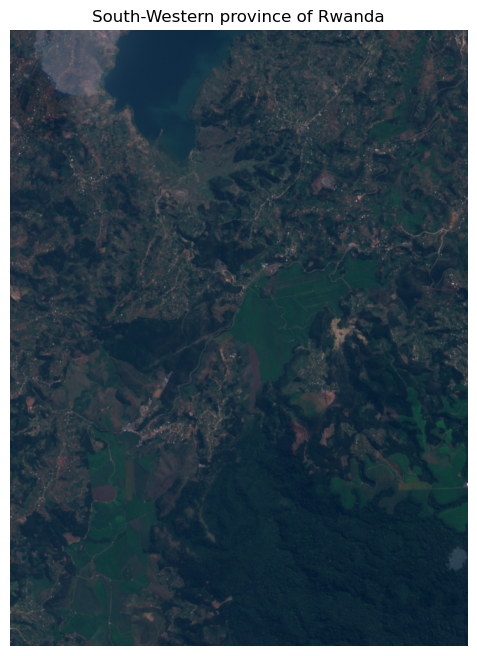

In [3]:
# Preview the sentinel image
 
red = image[8]
green = image[9]
blue = image[10]

rgb = np.stack([red, green, blue], axis=-1).astype(float)

# Normalize to 0–1 range
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())  

plt.figure(figsize=(12, 8))
plt.imshow(rgb)
plt.title("South-Western province of Rwanda")
plt.axis('off')
plt.show()

In [4]:
# Convert bands to float to avoid division errors

# Blue
b2 = image[10].astype(float) 

# Green
b3 = image[9].astype(float) 

# Red
b4 = image[8].astype(float) 

# NIR
b8 = image[4].astype(float)  

# SWIR
b11 = image[1].astype(float)  

In [5]:
# Calculate the indices

# NDVI 
ndvi = (b8 - b4) / (b8 + b4 + 1e-10)

# NDWI 
ndwi = (b3 - b8) / (b3 + b8 + 1e-10)

# NDBI 
ndbi = (b11 - b8) / (b11 + b8 + 1e-10)

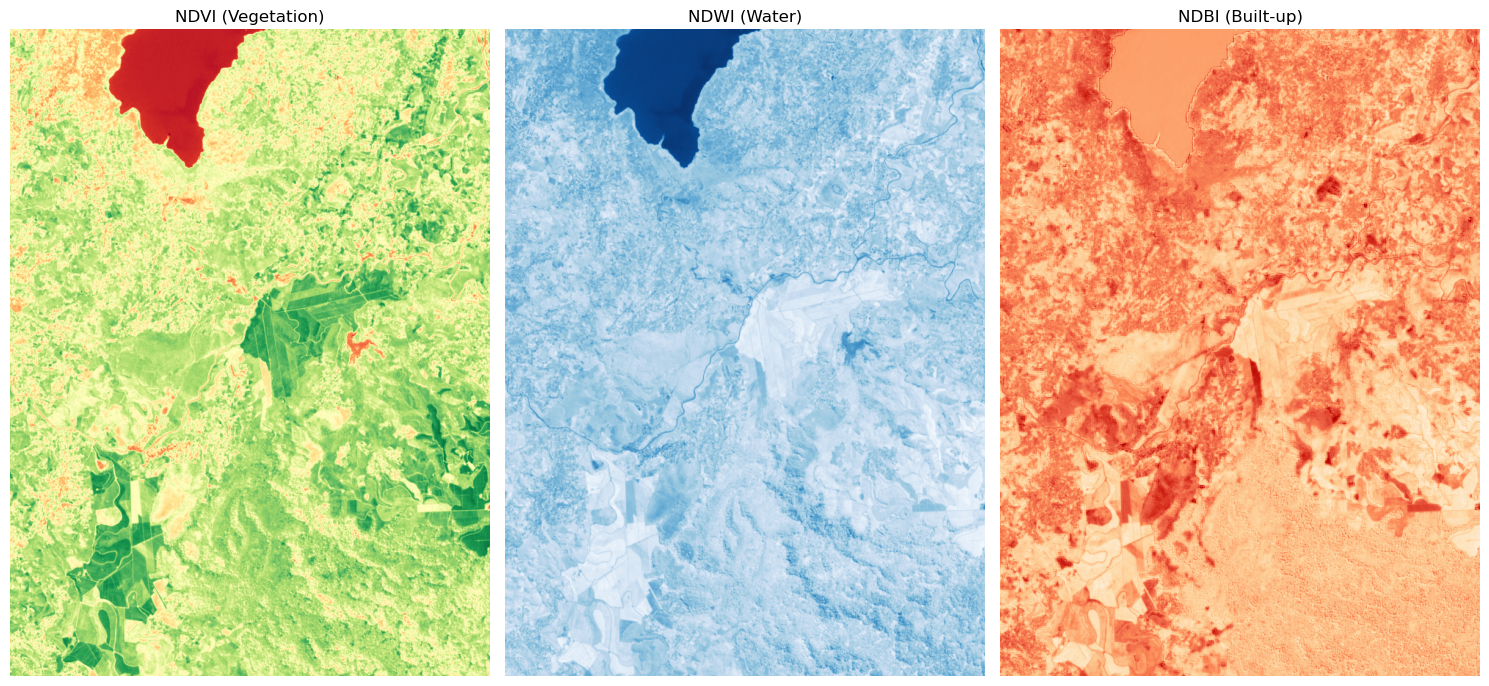

In [6]:
# Visualize all three indices
fig, axes = plt.subplots(1, 3, figsize=(15, 8))

axes[0].imshow(ndvi, cmap='RdYlGn')
axes[0].set_title("NDVI (Vegetation)")
axes[0].axis('off')

axes[1].imshow(ndwi, cmap='Blues')
axes[1].set_title("NDWI (Water)")
axes[1].axis('off')

axes[2].imshow(ndbi, cmap='OrRd')
axes[2].set_title("NDBI (Built-up)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [7]:
# Load the training points shapefile
shapefile_path = "train_val_final.shp"   

gdf = gpd.read_file(shapefile_path)

In [8]:
# Confirm the CRS of the shapefile
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

- Since the CRS are the same as the Sentinel 2 image there is no need to reproject. Let's view the data.

In [ ]:
gdf.head()

,category,geometry
0,forest,POINT (29.05868 -2.42512)
1,tea,POINT (29.06158 -2.42884)
2,tea,POINT (29.06205 -2.42944)
3,tea,POINT (29.06232 -2.43084)
4,tea,POINT (29.06508 -2.43202)


In [10]:
# Check the class distribution
print(f"\nClass distribution:")
print(gdf["category"].value_counts())


Class distribution:
category
forest    200
tea       200
other     200
water     200
Name: count, dtype: int64


- The class labels are also balanced with eact class having 200 values. Let's visualize the classes.

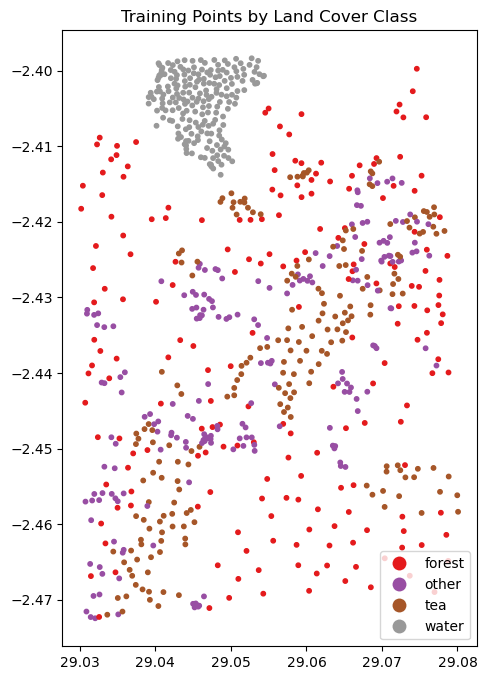

In [11]:
# Visualize 
fig, ax = plt.subplots(figsize=(12, 8))

gdf.plot(column=gdf["category"], ax=ax, legend=True, 
         cmap='Set1', markersize=10)
plt.title("Training Points by Land Cover Class")
plt.show()

### Data Preparation

In [12]:
# Stack all bands and indices into one big array
all_bands = np.stack([
    image[0], image[1], image[2], image[3],   
    image[4], image[5], image[6], image[7],
    image[8], image[9], image[10],
    ndvi, ndwi, ndbi                           
], axis=-1).astype(float)

all_bands.shape

(881, 654, 14)

In [13]:
# Extract the pixel values at each training point

features = []
labels   = []

with rasterio.open(image_path) as src:
    for i, row in gdf.iterrows():
        x, y = row.geometry.x, row.geometry.y

        # convert to pixel coordinates
        col, row_px = ~src.transform * (x, y)
        col, row_px = int(col), int(row_px)

        # check if inside image
        if 0 <= row_px < all_bands.shape[0] and 0 <= col < all_bands.shape[1]:
            pixel_values = all_bands[row_px, col]
            features.append(pixel_values)
            labels.append(row["category"])

X = np.array(features)   
y = np.array(labels)     

print(f"Total samples : {X.shape[0]}")
print(f"Features each : {X.shape[1]}")
print(f"Classes found : {np.unique(y)}")

Total samples : 800
Features each : 14
Classes found : ['forest' 'other' 'tea' 'water']


In [14]:
# Encode the class labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Preview the encoded classes
for i, classes in enumerate(le.classes_):
    print(f"{classes:15} : {i}")

forest          : 0
other           : 1
tea             : 2
water           : 3


### Model Training

In [15]:
# Define the model
rf_model = RandomForestClassifier(
    n_estimators=200,       
    max_depth=20,           
    min_samples_split=5,    
    class_weight='balanced',
    random_state=42,        
    n_jobs=-1               
)

In [16]:
# Cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X, y_encoded, cv=cv, scoring='accuracy')

print(f"Scores per fold : {np.round(cv_scores, 4)}")
print(f"Mean accuracy : {cv_scores.mean():.4f}")
print(f"Std deviation : {cv_scores.std():.4f}")

Scores per fold : [0.9    0.9375 0.9    0.9062 0.9062]
Mean accuracy : 0.9100
Std deviation : 0.0140


- Based on the cross validation results above, the model performs well approximately 91% accuracy and behaves consistently across the different subsets of the data.

In [17]:
# Train the model on all data
rf_model.fit(X, y_encoded)


RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_split=5, n_estimators=200, n_jobs=-1,
                       random_state=42)

### Model Evaluation

In [ ]:
# Perform prediction
y_pred = rf_model.predict(X)

print("Classification Report:")
print(classification_report(y_encoded, y_pred, target_names=le.classes_))

Classification Report:
              precision    recall  f1-score   support

      forest       1.00      0.99      1.00       200
       other       0.99      0.99      0.99       200
         tea       0.99      0.99      0.99       200
       water       1.00      1.00      1.00       200

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800



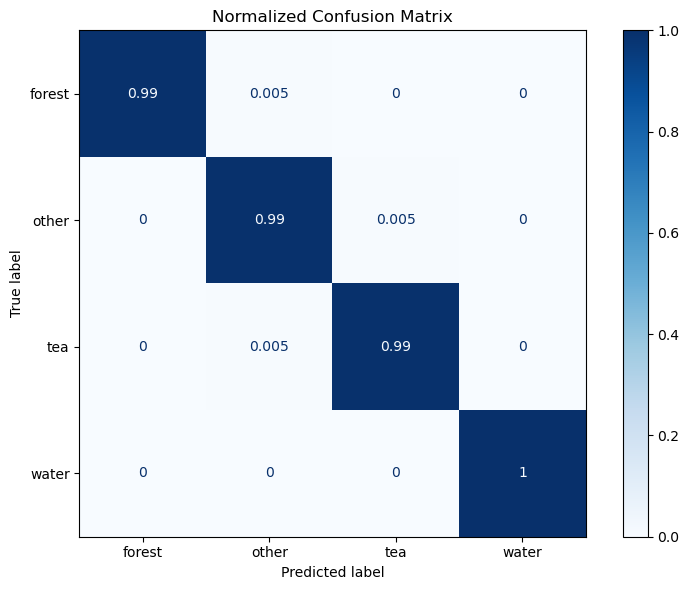

In [ ]:
# Plot the confusion matrix
cm = confusion_matrix(y_encoded, y_pred, normalize='true')

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', colorbar=True, ax=plt.gca())
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

- The results show that the model performs very well across all classes. From the confusion matrix, most of the values lie on the diagonal, meaning the model is correctly classifying nearly all samples. 

- Forest, other, and tea all achieve very high correct classification rates (0.99), with only minimal confusion between them (about 0.005 in a few cases), while water is perfectly classified with no misclassifications.

- The classification report confirms this strong performance, with precision, recall, and F1-scores all close to or equal to 1.00 for each class, and an overall accuracy of 100%. Since each class is evenly represented (200 samples each), the macro and weighted averages are also 1.00, showing consistent performance across all categories.

- Overall, the model demonstrates excellent predictive ability, though the perfect accuracy on the training data may suggest some level of overfitting, making the cross-validation accuracy of about 91% a more realistic indicator of how the model would perform on unseen data.


In [20]:
# Predict on the entire image
h, w, n_features = all_bands.shape

# Flatten the image
pixels = all_bands.reshape(-1, n_features)

# Clean up any bad values
pixels = np.nan_to_num(pixels, nan=0.0, posinf=0.0, neginf=0.0)

predictions = rf_model.predict(pixels)

# Reshape back to (height, width)
prediction_map = predictions.reshape(h, w)

In [ ]:
# Visualize the land cover map

# Map colors to the class labels
color_map = {
    0: mcolors.to_rgb('forestgreen'),   
    1: mcolors.to_rgb('grey'),          
    2: mcolors.to_rgb('darkgreen'),    
    3: mcolors.to_rgb('blue'),          
}

rgb_map = np.zeros((h, w, 3), dtype=np.float32)  

for class_idx, color in color_map.items():
    rgb_map[prediction_map == class_idx] = color  

plt.figure(figsize=(12, 8))
plt.imshow(rgb_map)
plt.title("Land Cover Classification Map — SW Rwanda", fontsize=16)
plt.axis('off')

# Legend
legend_elements = [
    Patch(facecolor=color_map[i], label=le.classes_[i])
    for i in range(len(le.classes_))
]

plt.legend(handles=legend_elements, loc='lower right', fontsize=12)
plt.tight_layout()
plt.show()

In [30]:
# Save the map as a .tiff file

path = "landcover_map.tif"

with rasterio.open(image_path) as src:
    out_meta = src.meta.copy()

out_meta.update({"count": 1, "dtype": "uint8"})

with rasterio.open(path, "w", **out_meta) as dest:
    dest.write(prediction_map.astype(np.uint8), 1)

print(f"Map saved to: {path}")

Map saved to: landcover_map.tif


### Additional Data Source Extraction.

#### Adding Missing “Buildings” Class to Training Data (QGIS)

The provided training dataset did not include the **buildings (buildup)** class, which was required for the project. Ideally, I would have extended the dataset manually using QGIS before proceeding with modeling. However, due to network connectivity issues, I was unable to download and install QGIS within the allocated time. Alternative approaches e.g OpenStreetMap were also not feasible under the time constraints.

As a result, the model was trained using only the four available classes. This means the results may differ from a full five-class model that includes buildings. Below are the steps I would have followed to incorporate the missing class.

#### Step 1 : Install QGIS
- Download QGIS (LTR version) from: https://qgis.org/download/  
- Install using default settings  

#### Step 2 : Load the Data
- Load the Sentinel-2 image  
  - `Layer → Add Layer → Add Raster Layer`  
  - Select `S2_srw.tif`  

- Load the training points  
  - `Layer → Add Layer → Add Vector Layer`  
  - Select `train_val.shp`  

#### Step 3 : Create a New Layer for Buildings
- `Layer → Create Layer → New Shapefile Layer`  

- Set:
  - Geometry: **Point**  
  - CRS: same as the Sentinel image (EPSG:4326)  
  - File name: `building_points.shp`  

- Add attribute:
  - Field name: `class`  
  - Type: **Text**  

#### Step 4 : Digitize Building Points
- Select the `building_points` layer  
- Enable **Edit Mode**  
- Use **Add Point Feature**  

- For each building:
  - Zoom into the satellite image  
  - Click on visible building structures  
  - Set:
    ```
    class = buildings
    ```

- Add approximately 20–30 points across the study area  

- Save edits and exit Edit Mode  

#### Step 5 : Merge with Original Training Data
- `Vector → Data Management Tools → Merge Vector Layers`  

- Input layers:
  - `train_val.shp`  
  - `building_points.shp`  

- Output: `train_val_final.shp`

#### Step 6 : Result
The final dataset would include all required classes:
- Forest  
- Tea  
- Water  
- Buildings  
- Other  